<a href="https://colab.research.google.com/github/Jaguar838/Assistant-AI/blob/main/app/restaurant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [ ]:
https://github.com/mate-academy/py-restaurant-data-analysis/blob/master/db.sqlite3

### Download the SQLite Database

First, I will download the `db.sqlite3` file from the provided GitHub URL using `wget`.

In [1]:
import os

db_url = 'https://github.com/mate-academy/py-restaurant-data-analysis/raw/master/db.sqlite3'
db_file_name = 'db.sqlite3'

# Check if the file already exists to avoid re-downloading
if not os.path.exists(db_file_name):
    !wget {db_url}
    print(f"Downloaded {db_file_name}")
else:
    print(f"{db_file_name} already exists.")

--2026-06-13 19:24:51--  https://github.com/mate-academy/py-restaurant-data-analysis/raw/master/db.sqlite3
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mate-academy/py-restaurant-data-analysis/master/db.sqlite3 [following]
--2026-06-13 19:24:52--  https://raw.githubusercontent.com/mate-academy/py-restaurant-data-analysis/master/db.sqlite3
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6410240 (6.1M) [application/octet-stream]
Saving to: ‘db.sqlite3’

db.sqlite3          100%[===================>]   6.11M  --.-KB/s    in 0.1s    

2026-06-13 19:24:52 (48.2 MB/s) - ‘db.sqlite3’ saved [6410240/

### Connect to the Database and Extract Tables

Now, I will connect to the `db.sqlite3` database and read its tables into pandas DataFrames. I'll inspect the tables to understand their structure and relationships.

In [4]:
import sqlite3

# Connect to the SQLite database
conn = sqlite3.connect(db_file_name)

# Get a list of all tables in the database
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
table_names = [table[0] for table in tables]
print("Tables in the database:", table_names)

# Read each table into a pandas DataFrame
dfs = {}
for table_name in table_names:
    dfs[table_name] = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    print(f"\n{table_name} DataFrame head:")
    display(dfs[table_name].head())

conn.close()

Tables in the database: ['sqlite_sequence', 'restaurant_orderitem', 'restaurant_product', 'restaurant_order']

sqlite_sequence DataFrame head:


,name,seq
0,restaurant_product,248
1,restaurant_orderitem,74818
2,restaurant_order,13397



restaurant_orderitem DataFrame head:


,id,quantity,order_id,product_id
0,1,2,1,6
1,2,1,1,240
2,3,1,1,19
3,4,1,1,36
4,5,1,1,111



restaurant_product DataFrame head:


,id,price,name
0,1,0.5,Mint Sauce
1,2,0.5,Lime Pickle
2,3,0.5,Mango Chutney
3,4,0.5,Red Sauce
4,5,0.5,Onion Chutney



restaurant_order DataFrame head:


,id,datetime
0,1,2019-08-03 20:25:00
1,2,2019-08-03 20:17:00
2,3,2019-08-03 20:09:00
3,4,2019-08-03 20:01:00
4,5,2019-08-03 19:44:00


### Combine Data from Tables

I will now combine the `Orders`, `OrderItems`, `Products`, and `ProductCategories` tables into a single DataFrame using appropriate joins. Based on the table structures, I will perform `INNER JOIN` operations to ensure only matching records are included.

In [6]:
# Start with OrderItems using the correct key from the database
combined_df = dfs['restaurant_orderitem']

# Join with Products table
combined_df = pd.merge(
    combined_df,
    dfs['restaurant_product'],
    left_on='product_id',
    right_on='id',
    how='inner',
    suffixes=('_item', '_product')
)

# Join with Orders table
combined_df = pd.merge(
    combined_df,
    dfs['restaurant_order'],
    left_on='order_id',
    right_on='id',
    how='inner',
    suffixes=('_combined', '_order')
)

# Rename columns for clarity as per task requirement
combined_df = combined_df.rename(columns={
    'name': 'ProductName',
    'price': 'ProductPrice',
    'quantity': 'Quantity',
    'date_time': 'OrderDateTime'
})

print("Combined DataFrame head:")
display(combined_df.head())
print(f"\nShape of the combined DataFrame: {combined_df.shape}")

Combined DataFrame head:


,id_item,Quantity,order_id,product_id,id_product,ProductPrice,ProductName,id,datetime
0,1,2,1,6,6,0.80,Plain Papadum,1,2019-08-03 20:25:00
1,2,1,1,240,240,12.95,King Prawn Balti,1,2019-08-03 20:25:00
2,3,1,1,19,19,2.95,Garlic Naan,1,2019-08-03 20:25:00
3,4,1,1,36,36,3.95,Mushroom Rice,1,2019-08-03 20:25:00
4,5,1,1,111,111,8.95,Paneer Tikka Masala,1,2019-08-03 20:25:00



Shape of the combined DataFrame: (74818, 9)


### Save to CSV and Load into DataFrame

Finally, I will save the combined DataFrame to a CSV file and then read it back into a new DataFrame to fulfill the task requirements. This also serves as a quick check for the specified row count (74818).

In [7]:
output_csv_file = 'combined_restaurant_data.csv'
combined_df.to_csv(output_csv_file, index=False)
print(f"Combined data saved to '{output_csv_file}'")

# Read the CSV back into a new DataFrame
df = pd.read_csv(output_csv_file)

print("\nDataFrame loaded from CSV (first 5 rows):")
display(df.head())
print(f"\nShape of the final DataFrame: {df.shape}")

# Quick check for the number of rows
expected_rows = 74818
if df.shape[0] == expected_rows:
    print(f"The DataFrame has {df.shape[0]} rows, which matches the expected {expected_rows} rows.")
else:
    print(f"Warning: The DataFrame has {df.shape[0]} rows, but {expected_rows} were expected.")

Combined data saved to 'combined_restaurant_data.csv'

DataFrame loaded from CSV (first 5 rows):


,id_item,Quantity,order_id,product_id,id_product,ProductPrice,ProductName,id,datetime
0,1,2,1,6,6,0.80,Plain Papadum,1,2019-08-03 20:25:00
1,2,1,1,240,240,12.95,King Prawn Balti,1,2019-08-03 20:25:00
2,3,1,1,19,19,2.95,Garlic Naan,1,2019-08-03 20:25:00
3,4,1,1,36,36,3.95,Mushroom Rice,1,2019-08-03 20:25:00
4,5,1,1,111,111,8.95,Paneer Tikka Masala,1,2019-08-03 20:25:00



Shape of the final DataFrame: (74818, 9)
The DataFrame has 74818 rows, which matches the expected 74818 rows.


# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](https://github.com/mate-academy/py-restaurant-data-analysis/blob/master/demo/pie.png?raw=1)

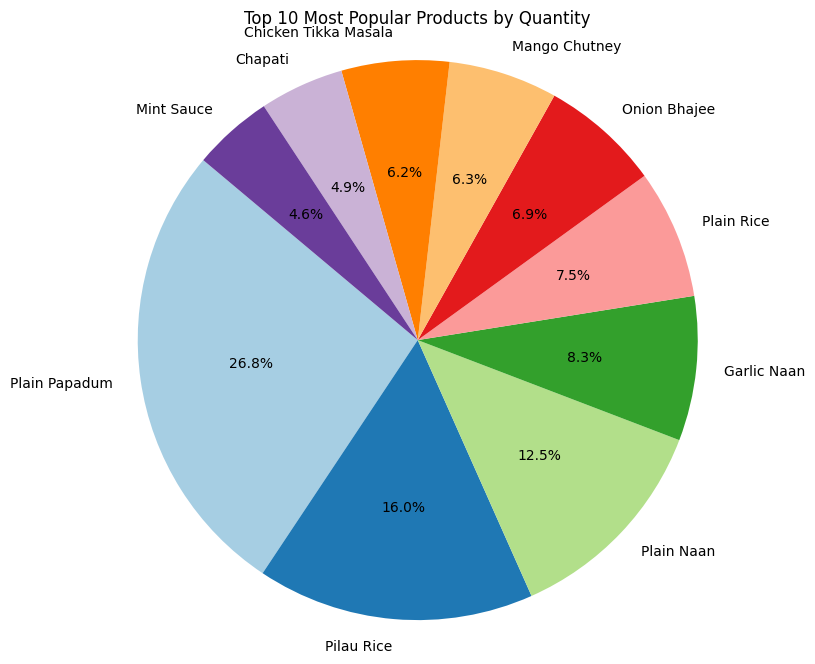

Top 10 products by quantity sold:
ProductName
Plain Papadum           10648
Pilau Rice               6367
Plain Naan               4983
Garlic Naan              3318
Plain Rice               2964
Onion Bhajee             2749
Mango Chutney            2504
Chicken Tikka Masala     2473
Chapati                  1935
Mint Sauce               1840
Name: Quantity, dtype: int64


In [8]:
import matplotlib.pyplot as plt

# Group by ProductName and sum the Quantity
top_10_quantity = df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)

# Create a pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    top_10_quantity,
    labels=top_10_quantity.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)
plt.title('Top 10 Most Popular Products by Quantity')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Display the counts as well
print("Top 10 products by quantity sold:")
print(top_10_quantity)

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

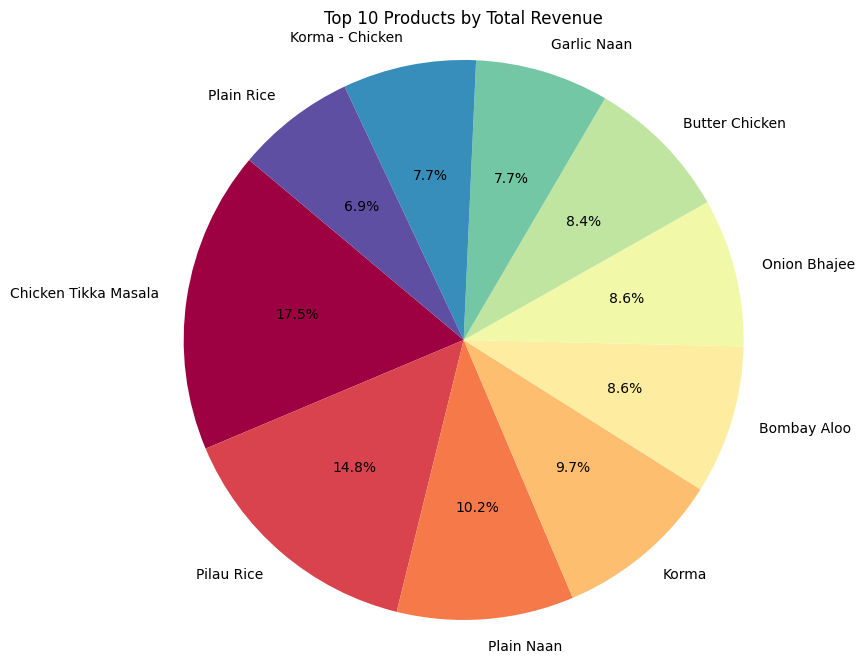

Top 10 products by revenue:
ProductName
Chicken Tikka Masala    22133.35
Pilau Rice              18782.65
Plain Naan              12955.80
Korma                   12261.50
Bombay Aloo             10894.45
Onion Bhajee            10858.55
Butter Chicken          10626.60
Garlic Naan              9788.10
Korma - Chicken          9764.45
Plain Rice               8743.80
Name: ItemPrice, dtype: float64


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate revenue for each item
df['ItemPrice'] = df['ProductPrice'] * df['Quantity']

# Group by product name and sum the revenue
top_10_revenue = df.groupby('ProductName')['ItemPrice'].sum().sort_values(ascending=False).head(10)

# Create a pie chart for revenue
plt.figure(figsize=(10, 8))

# Get colors from a colormap
colormap = plt.get_cmap('Spectral')
colors = [colormap(i) for i in np.linspace(0, 1, len(top_10_revenue))]

plt.pie(
    top_10_revenue,
    labels=top_10_revenue.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)
plt.title('Top 10 Products by Total Revenue')
plt.axis('equal')
plt.show()

# Display values
print("Top 10 products by revenue:")
print(top_10_revenue)

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](https://github.com/mate-academy/py-restaurant-data-analysis/blob/master/demo/bar.png?raw=1)

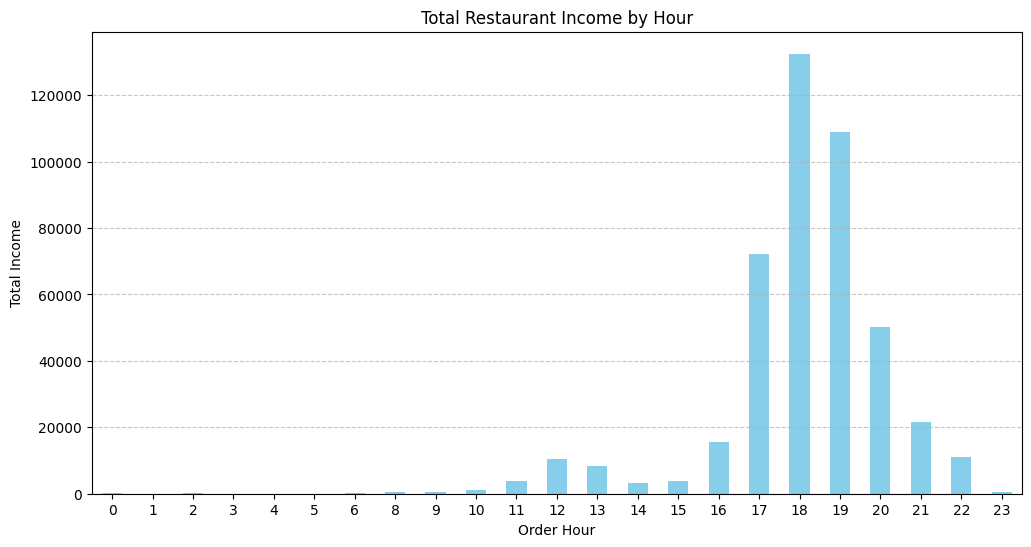

Income by hour:
Order Hour
0        177.95
1         54.65
2        199.25
3          8.90
4         63.45
5         57.40
6        121.60
8        447.70
9        570.60
10      1250.35
11      3807.05
12     10565.85
13      8282.65
14      3343.55
15      3781.70
16     15634.75
17     72110.20
18    132462.50
19    109045.05
20     50218.25
21     21480.30
22     11001.50
23       373.25
Name: ItemPrice, dtype: float64


In [12]:
import matplotlib.pyplot as plt

# Convert 'datetime' column to datetime objects
df['datetime'] = pd.to_datetime(df['datetime'])

# Extract the hour (0-23)
df['Order Hour'] = df['datetime'].dt.hour

# Group by Order Hour and calculate total income
hourly_income = df.groupby('Order Hour')['ItemPrice'].sum()

# Create the bar chart
plt.figure(figsize=(12, 6))
hourly_income.plot(kind='bar', color='skyblue')
plt.title('Total Restaurant Income by Hour')
plt.xlabel('Order Hour')
plt.ylabel('Total Income')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display the hourly income data
print("Income by hour:")
print(hourly_income)

# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

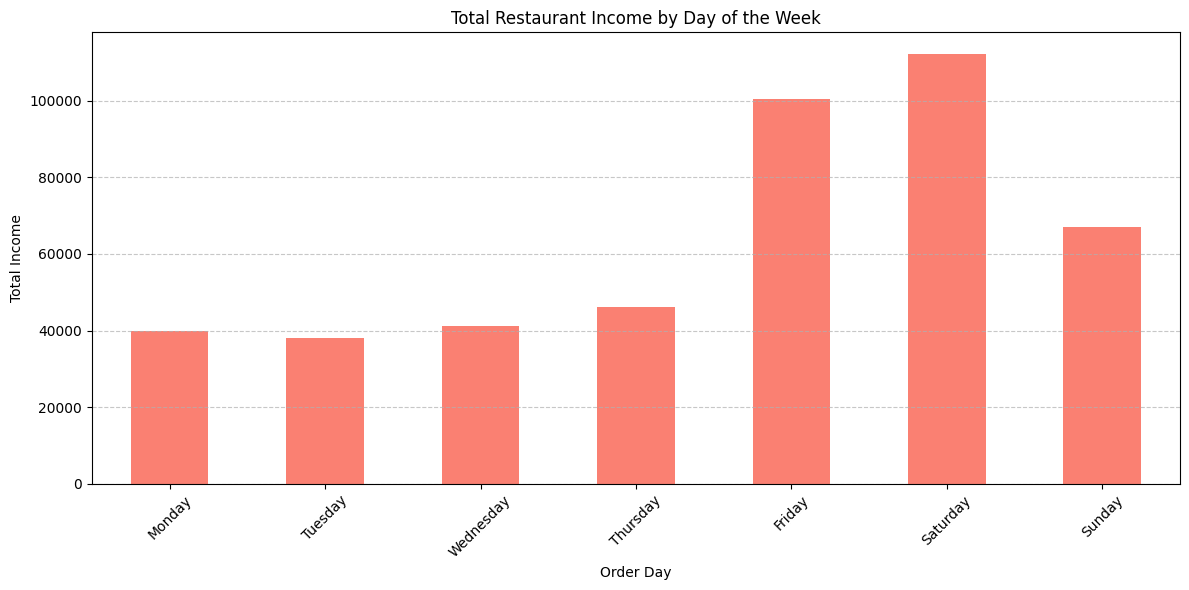

Income by day of the week:
Order Day
Monday        40008.30
Tuesday       38145.65
Wednesday     41246.20
Thursday      46021.55
Friday       100339.15
Saturday     112191.65
Sunday        67105.95
Name: ItemPrice, dtype: float64


In [13]:
import matplotlib.pyplot as plt

# Extract the day of the week name (e.g., Monday, Tuesday)
df['Order Day'] = df['datetime'].dt.day_name()

# Define the order of days for the chart
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group by Order Day and calculate total income, then reorder according to days_order
daily_income = df.groupby('Order Day')['ItemPrice'].sum().reindex(days_order)

# Create the bar chart
plt.figure(figsize=(12, 6))
daily_income.plot(kind='bar', color='salmon')
plt.title('Total Restaurant Income by Day of the Week')
plt.xlabel('Order Day')
plt.ylabel('Total Income')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display the daily income data
print("Income by day of the week:")
print(daily_income)